# Booking Status Binary Classification

## EDA & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/first inten project.csv')

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.columns

In [ ]:
df.dtypes

In [ ]:
df.isnull().sum()

No Missing values

In [ ]:
## Renaming average price column
df.rename(columns={'average price ': 'average price'}, inplace=True)

### Univariate Analysis

#### Target Feature disturbution

In [ ]:
booking_status = df['booking status'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(booking_status, labels=booking_status.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Percentage of Cancelled Rooms', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
df['booking status'].value_counts()


Needs resampling to avoid class imbalances

#### Number of People

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
number_of_children = df['number of children'].value_counts().sort_index()
plt.bar(number_of_children.index, number_of_children.values, color='skyblue', edgecolor='black')
plt.xlabel('Number of Children', fontsize=12)
plt.xticks(np.arange(0, 11))
plt.title('Bar Chart of Number of Children', fontsize=14)
for i, v in enumerate(number_of_children.values):
    plt.text(number_of_children.index[i], v, str(v), ha='center', va='bottom', fontsize=10)


plt.subplot(1, 2, 2)  # 1 row, 2 columns, first subplot
number_of_adults = df['number of adults'].value_counts().sort_index()
plt.bar(number_of_adults.index, number_of_adults.values, color='skyblue', edgecolor='black')
plt.xlabel('Number of Adults', fontsize=12)
plt.xticks(np.arange(0, 11))
plt.title('Bar Chart of Number of Adults', fontsize=14)
for i, v in enumerate(number_of_adults.values):
    plt.text(number_of_adults.index[i], v, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()  # Adjust subplot parameters for a tight layout
plt.show()

Remove the records with 9 and 10 children as they are outliers

In [ ]:
df = df[df['number of children'] < 9]

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
number_of_children = df['number of children'].value_counts().sort_index()
plt.bar(number_of_children.index, number_of_children.values, color='skyblue', edgecolor='black')
plt.xlabel('Number of Children', fontsize=12)
plt.xticks(np.arange(0, 4))
plt.title('Bar Chart of Number of Children', fontsize=14)
for i, v in enumerate(number_of_children.values):
    plt.text(number_of_children.index[i], v, str(v), ha='center', va='bottom', fontsize=10)


plt.subplot(1, 2, 2)  # 1 row, 2 columns, first subplot
number_of_adults = df['number of adults'].value_counts().sort_index()
plt.bar(number_of_adults.index, number_of_adults.values, color='skyblue', edgecolor='black')
plt.xlabel('Number of Adults', fontsize=12)
plt.xticks(np.arange(0, 11))
plt.title('Bar Chart of Number of Adults', fontsize=14)
for i, v in enumerate(number_of_adults.values):
    plt.text(number_of_adults.index[i], v, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()  # Adjust subplot parameters for a tight layout
plt.show()

#### Disturbution of booking nights

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
number_of_weekend_nights = df['number of weekend nights'].value_counts().sort_index()
plt.bar(number_of_weekend_nights.index, number_of_weekend_nights.values, color='skyblue', edgecolor='black')
plt.xlabel('Number of Weekend Nights', fontsize=12)
plt.xticks(np.arange(0, 8))
plt.title('Bar Chart of Number of Weekend Nights', fontsize=14)
for i, v in enumerate(number_of_weekend_nights.values):
    plt.text(number_of_weekend_nights.index[i], v, str(v), ha='center', va='bottom', fontsize=10)


plt.subplot(1, 2, 2)  # 1 row, 2 columns, first subplot
number_of_adults = df['number of week nights'].value_counts().sort_index()
plt.bar(number_of_adults.index, number_of_adults.values, color='skyblue', edgecolor='black')
plt.xlabel('Number of Week Nights', fontsize=12)
plt.xticks(np.arange(0, 18))
plt.title('Bar Chart of Number of Week Nights', fontsize=14)
for i, v in enumerate(number_of_adults.values):
    plt.text(number_of_adults.index[i], v, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()  # Adjust subplot parameters for a tight layout
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
sns.boxplot(x=df['number of weekend nights'])
plt.xlabel('Number of WeekEnd Nights', fontsize=12)
plt.title('Box Plot of Number of WeekEnd Nights', fontsize=14)


plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
sns.boxplot(x=df['number of week nights'])
plt.xlabel('Number of Week Nights', fontsize=12)
plt.title('Box Plot of Number of Week Nights', fontsize=14)

plt.tight_layout()  # Adjust subplot parameters for a tight layout
plt.show()

In [ ]:
# Check if there is a booking with 0 weekend nights and 0 week nights at

print(f"There are {((df['number of weekend nights'] + df['number of week nights']) == 0).sum()} bookings with 0 weekend nights and 0 week nights")

Remove the bookings with 0 nights

In [ ]:
df = df[(df['number of weekend nights'] + df['number of week nights']) > 0]

#### Disturbution of Lead times

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['lead time'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Lead Time', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Lead Times', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Disturbution of Meal Types

In [ ]:
plt.figure(figsize=(10, 6))
meal_plans_count = df['type of meal'].value_counts().sort_index()
plt.bar(meal_plans_count.index, meal_plans_count.values, color='skyblue', edgecolor='black')
plt.xlabel('Meal Plan', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.title('Distribution of Meal Plans', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
for i, v in enumerate(meal_plans_count.values):
    plt.text(meal_plans_count.index[i], v, str(v), ha='center', va='bottom', fontsize=10)
plt.grid(axis='y', alpha=0.75)
plt.show()

### Bivariate Analysis with Target

#### Meal Plan with cancellation

In [ ]:
# Get unique market segments
meal_plan = df['type of meal'].unique()
num_segments = len(meal_plan)

# Create a 3x2 grid, then remove unwanted subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 12))  # 3 rows, 2 columns

# Remove unwanted subplots (3,0) and (3,2)
fig.delaxes(axes[2, 0])  # Remove subplot at (3, 0)
fig.delaxes(axes[2, 1])  # Remove subplot at (3, 2)

# Iterate through market segments and plot pie charts
for i, segment in enumerate(meal_plan):
    if i < 4:  # First 4 segments in 2x2 grid
        row = i // 2
        col = i % 2
        ax = axes[row, col]
    else:  # Last segment in bottom middle
        ax = fig.add_subplot(3, 2, 5)  # Add subplot at position 5
    segment_data = df[df['type of meal'] == segment]
    booking_status_counts = segment_data['booking status'].value_counts()
    ax.pie(booking_status_counts, labels=booking_status_counts.index, startangle=90, colors=['skyblue', 'lightcoral'])
    ax.set_title(f'Meal: {segment}')

plt.show()

In [ ]:
room_type = df['room type'].unique()
num_rooms = len(room_type)

# Calculate the number of rows and columns for the subplot grid
num_cols = 3  # Number of columns
num_rows = (num_rooms + num_cols - 1) // num_cols  # Number of rows (ceiling division)

# Create the subplot grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 12))  # Adjusted figsize

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through room types and plot pie charts
for i, room in enumerate(room_type):
    ax = axes[i]  # Assign axis directly
    room_data = df[df['room type'] == room]
    booking_status_counts = room_data['booking status'].value_counts()
    ax.pie(booking_status_counts, labels=booking_status_counts.index, startangle=90, colors=['skyblue', 'lightcoral'])
    ax.set_title(f'Room: {room}')

# Remove any extra subplots if necessary
for j in range(num_rooms, num_rows * num_cols):
    fig.delaxes(axes[j])

plt.tight_layout()  # Adjust subplot spacing
plt.show()

## Feature Engineering & Feature Selection

#### Total Number of people

In [ ]:
df['total_people'] = df['number of adults'] + df['number of children']

# Group by the 'total_people' column and count the occurrences
people_counts = df.groupby('total_people')['total_people'].count()


plt.figure(figsize=(10, 6))
plt.bar(people_counts.index, people_counts.values, color='skyblue', edgecolor='black', )
plt.xlabel('Number of People (Adults + Children)', fontsize=12)
plt.xticks(np.arange(0, 6))
for i, v in enumerate(people_counts.values):
    plt.text(people_counts.index[i], v, str(v), ha='center', fontsize=10)
plt.ylabel('Number of Bookings', fontsize=12)  # Or 'Frequency'
plt.title('Distribution of Total People per Booking', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Total number of nights

In [ ]:
df['total_nights'] = df['number of weekend nights'] + df['number of week nights']

# Group by the 'total_people' column and count the occurrences
night_counts = df.groupby('total_nights')['total_nights'].count()


plt.figure(figsize=(10, 6))
plt.bar(night_counts.index, night_counts.values, color='skyblue', edgecolor='black', )
plt.xlabel('Number of Total Nights (Week + WeekEnd)', fontsize=12)
plt.xticks(np.arange(0, max(night_counts.index)+1))
for i, v in enumerate(night_counts.values):
    plt.text(night_counts.index[i], v, str(v), ha='center', fontsize=10)
plt.ylabel('Number of Bookings', fontsize=12)  # Or 'Frequency'
plt.title('Distribution of Total Nights per Booking', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Compute skewness
print("Skewness of Total Nights:", df['total_nights'].skew())

Needs to be skewed

#### Date-Realated features

Check if date is in the correct format

In [517]:
def check_date_format(df, date_column):
  """
  Checks if the dates in a column are in the correct format.

  Args:
    df: The pandas DataFrame.
    date_column: The name of the date column.

  Returns:
    A pandas Series containing True for correctly formatted dates and False otherwise.
  """
  results = []
  for date_str in df[date_column]:
    try:
      pd.to_datetime(date_str, format='%m/%d/%Y')  # Correct format string
      results.append(True)
    except ValueError:
      results.append(False)
  return pd.Series(results, index=df.index)

# Apply the function to your date columns
date_check_results = check_date_format(df, 'date of reservation')

# Filter for incorrect dates
incorrect_dates = df[~date_check_results]['date of reservation']

# Print the incorrect dates
print(incorrect_dates)
print(len(incorrect_dates))

2626     2018-2-29
3677     2018-2-29
5600     2018-2-29
6343     2018-2-29
7648     2018-2-29
8000     2018-2-29
8989     2018-2-29
9153     2018-2-29
9245     2018-2-29
9664     2018-2-29
9934     2018-2-29
10593    2018-2-29
10652    2018-2-29
10747    2018-2-29
11881    2018-2-29
13958    2018-2-29
14304    2018-2-29
15363    2018-2-29
15438    2018-2-29
17202    2018-2-29
18380    2018-2-29
18534    2018-2-29
18680    2018-2-29
19013    2018-2-29
20419    2018-2-29
21674    2018-2-29
21688    2018-2-29
26108    2018-2-29
27559    2018-2-29
27928    2018-2-29
30552    2018-2-29
30616    2018-2-29
30632    2018-2-29
30839    2018-2-29
32041    2018-2-29
34638    2018-2-29
35481    2018-2-29
Name: date of reservation, dtype: object
37


2018-2 doesn't have the day 29
Returning to the next month

In [518]:
df.loc[df['date of reservation'].astype(str) == '2018-2-29', 'date of reservation'] = '3/1/2018'

In [519]:
df['date of reservation'] = pd.to_datetime(df['date of reservation'])

Add the booking month as a feature

In [520]:
df['booking_month'] = pd.to_datetime(df['date of reservation']).dt.month

Add the booking season as a feature

In [521]:
df['booking_season'] = df['booking_month'].apply(lambda x: 'Winter' if x in [12,1,2]
                                                 else 'Spring' if x in [3,4,5]
                                                 else 'Summer' if x in [6,7,8]
                                                 else 'Fall')

Add day of the booking as a feature

In [522]:
df['booking_day_of_week'] = pd.to_datetime(df['date of reservation']).dt.dayofweek

#### Guest-related features

In [523]:
df['only children'] = df.apply(lambda x: 1 if x['number of adults'] == 0 else 0, axis=1)

A feature if it is a family booking

In [524]:
df['is_family'] = df.apply(lambda x: 1 if x['number of adults'] > 1 and x['number of children'] > 0 else 0, axis=1)


A feature representing price per person

In [525]:
df['price_per_person'] = df['average price'] / df['total_people']

Converting lead times into bins

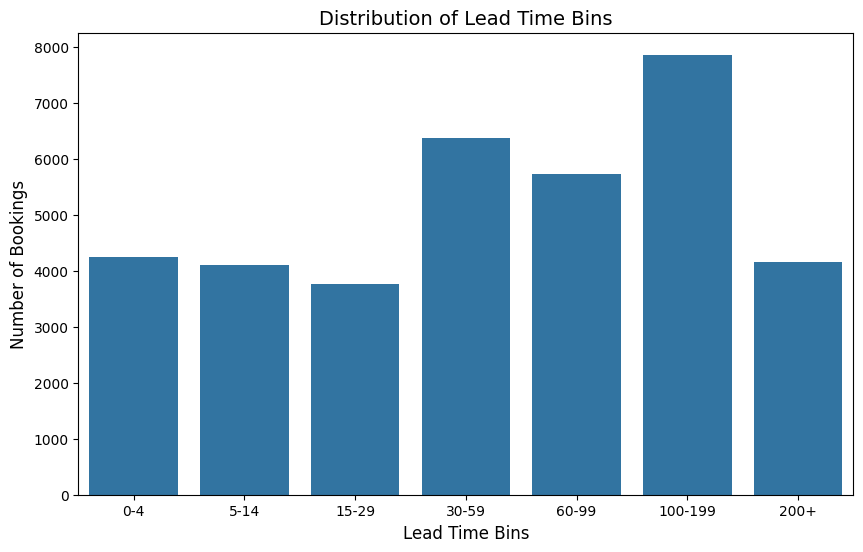

In [526]:
# prompt: I want to convert lead times into bins and visualizing it

# Define bin edges and labels
bin_edges = [0, 5, 15, 30, 60, 100, 200,  float('inf')]
bin_labels = ['0-4', '5-14', '15-29', '30-59', '60-99', '100-199', '200+']

# Create the lead time bins
df['lead_time_bins'] = pd.cut(df['lead time'], bins=bin_edges, labels=bin_labels, right=False)

# Visualize the distribution of lead time bins
plt.figure(figsize=(10, 6))
sns.countplot(x='lead_time_bins', data=df, order=bin_labels)
plt.xlabel('Lead Time Bins', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.title('Distribution of Lead Time Bins', fontsize=14)
plt.show()

### Dropping unused features

In [527]:
# Droping Booking_ID
df = df.drop(columns=[
    'Booking_ID', 'date of reservation', 'lead_time_bins', 'number of adults',
    'number of children', 'number of weekend nights', 'number of week nights',
    'P-C', 'P-not-C', 'price_per_person', 'total_people'
    ])


### Solve the Skewness problem

In [528]:
# prompt: check the skew of each variable, if it exceeds 1 then apply log transform for specific columns

from scipy.stats import skew

# Identify columns to check for skewness (excluding non-numeric and categorical columns)
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop([
    'is_family', 'booking_month', 'booking_day_of_week', 'only children'
    ])

for col in numeric_cols:
    sk = skew(df[col])
    print(f"Skewness of {col}: {sk}")
    if abs(sk) > 1:
        print(f"Applying log transform to {col}")
        # Apply log transform, handling potential zero values
        df[col] = np.log1p(df[col])  # log1p is more numerically stable for small values


Skewness of car parking space: 5.407587767373005
Applying log transform to car parking space
Skewness of lead time: 1.2913114191925334
Applying log transform to lead time
Skewness of repeated: 6.010277936849001
Applying log transform to repeated
Skewness of average price: 0.7228531689054554
Skewness of special requests: 1.1459180067890653
Applying log transform to special requests
Skewness of total_nights: 2.2501353671310684
Applying log transform to total_nights


### Encoding Categorical Features

In [529]:
df.head()

,type of meal,car parking space,room type,lead time,market segment type,repeated,average price,special requests,booking status,total_nights,booking_month,booking_season,booking_day_of_week,only children,is_family
0,Meal Plan 1,0.0,Room_Type 1,5.416100,Offline,0.0,88.00,0.000000,Not_Canceled,2.079442,10,Fall,4,0,0
1,Not Selected,0.0,Room_Type 1,1.791759,Online,0.0,106.68,0.693147,Not_Canceled,1.609438,11,Fall,1,0,0
2,Meal Plan 1,0.0,Room_Type 1,0.693147,Online,0.0,50.00,0.000000,Canceled,1.609438,2,Winter,2,0,1
3,Meal Plan 1,0.0,Room_Type 1,5.356586,Online,0.0,100.00,0.693147,Canceled,1.098612,5,Spring,5,0,0
4,Not Selected,0.0,Room_Type 1,3.891820,Online,0.0,77.00,0.000000,Canceled,1.386294,4,Spring,2,0,0


In [530]:
# One-hot encode 'type of meal' and 'room type'
df = pd.get_dummies(df, columns=['type of meal', 'room type'], prefix='meal')


In [537]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
encoder = LabelEncoder()

# Fit and transform the 'market segment' column
df['market segment type'] = encoder.fit_transform(df['market segment type'])
df['booking_season'] = encoder.fit_transform(df['booking_season'])
df['booking status'] = encoder.fit_transform(df['booking status'])
# df['lead_time_bins'] = encoder.fit_transform(df['lead_time_bins'])

# Now 'market_segment_encoded' contains the encoded values
# You can use this new column in your model

df.head()


,car parking space,lead time,market segment type,repeated,average price,special requests,booking status,total_nights,booking_month,booking_season,...,meal_Meal Plan 2,meal_Meal Plan 3,meal_Not Selected,meal_Room_Type 1,meal_Room_Type 2,meal_Room_Type 3,meal_Room_Type 4,meal_Room_Type 5,meal_Room_Type 6,meal_Room_Type 7
0,0.0,0.693851,3,0.0,-0.295403,0.000000,1,1.356915,10,0,...,False,False,False,True,False,False,False,False,False,False
1,0.0,-1.161156,4,0.0,0.179070,0.693147,1,0.436829,11,0,...,False,False,True,True,False,False,False,False,False,False
2,0.0,-1.723446,4,0.0,-1.260605,0.000000,0,0.436829,2,3,...,False,False,False,True,False,False,False,False,False,False
3,0.0,0.663391,4,0.0,0.009398,0.693147,0,-0.563171,5,1,...,False,False,False,True,False,False,False,False,False,False
4,0.0,-0.086304,4,0.0,-0.574803,0.000000,0,0.000000,4,1,...,False,False,True,True,False,False,False,False,False,False


In [538]:
print(df.columns)
# print(df['lead_time_bins'])

Index(['car parking space', 'lead time', 'market segment type', 'repeated',
       'average price', 'special requests', 'booking status', 'total_nights',
       'booking_month', 'booking_season', 'booking_day_of_week',
       'only children', 'is_family', 'meal_Meal Plan 1', 'meal_Meal Plan 2',
       'meal_Meal Plan 3', 'meal_Not Selected', 'meal_Room_Type 1',
       'meal_Room_Type 2', 'meal_Room_Type 3', 'meal_Room_Type 4',
       'meal_Room_Type 5', 'meal_Room_Type 6', 'meal_Room_Type 7'],
      dtype='object')


### Scaling the features

In [539]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# Fit the scaler to the 'average price' and 'total_nights' columns
scaler.fit(df[['average price', 'total_nights', 'lead time']])

# Transform the columns using the fitted scaler
df[['average price', 'total_nights', 'lead time']] = scaler.transform(df[['average price', 'total_nights', 'lead time']])

df.head()

,car parking space,lead time,market segment type,repeated,average price,special requests,booking status,total_nights,booking_month,booking_season,...,meal_Meal Plan 2,meal_Meal Plan 3,meal_Not Selected,meal_Room_Type 1,meal_Room_Type 2,meal_Room_Type 3,meal_Room_Type 4,meal_Room_Type 5,meal_Room_Type 6,meal_Room_Type 7
0,0.0,0.693851,3,0.0,-0.295403,0.000000,1,1.356915,10,0,...,False,False,False,True,False,False,False,False,False,False
1,0.0,-1.161156,4,0.0,0.179070,0.693147,1,0.436829,11,0,...,False,False,True,True,False,False,False,False,False,False
2,0.0,-1.723446,4,0.0,-1.260605,0.000000,0,0.436829,2,3,...,False,False,False,True,False,False,False,False,False,False
3,0.0,0.663391,4,0.0,0.009398,0.693147,0,-0.563171,5,1,...,False,False,False,True,False,False,False,False,False,False
4,0.0,-0.086304,4,0.0,-0.574803,0.000000,0,0.000000,4,1,...,False,False,True,True,False,False,False,False,False,False


## Classification Model

In [540]:
X = df.drop('booking status', axis=1)
y = df['booking status']

In [541]:
X.columns

Index(['car parking space', 'lead time', 'market segment type', 'repeated',
       'average price', 'special requests', 'total_nights', 'booking_month',
       'booking_season', 'booking_day_of_week', 'only children', 'is_family',
       'meal_Meal Plan 1', 'meal_Meal Plan 2', 'meal_Meal Plan 3',
       'meal_Not Selected', 'meal_Room_Type 1', 'meal_Room_Type 2',
       'meal_Room_Type 3', 'meal_Room_Type 4', 'meal_Room_Type 5',
       'meal_Room_Type 6', 'meal_Room_Type 7'],
      dtype='object')

In [542]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='auto')
X_res, y_res = smote.fit_resample(X, y)


In [543]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
logreg_model = LogisticRegression(max_iter=1000)  # Increased max_iter
logreg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logreg_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
conf_matrix


Accuracy: 0.776110197368421
              precision    recall  f1-score   support

           0       0.76      0.81      0.79      4934
           1       0.79      0.74      0.77      4794

    accuracy                           0.78      9728
   macro avg       0.78      0.78      0.78      9728
weighted avg       0.78      0.78      0.78      9728

Confusion Matrix:


array([[3984,  950],
       [1228, 3566]])

In [549]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, stratify=y_res)
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      4864
           1       0.91      0.93      0.92      4864

    accuracy                           0.92      9728
   macro avg       0.92      0.92      0.92      9728
weighted avg       0.92      0.92      0.92      9728

